In [1]:
import scanpy as sc
#import pycisTopic
#from pycisTopic.cistopic_class import *
import pickle
import os
import anndata
import mudata
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import ArrowStyle
from scipy import sparse
from scipy.stats import fisher_exact
import seaborn as sns
import glob
import PyComplexHeatmap as pch
from matplotlib.colors import LinearSegmentedColormap


In [2]:
REGION_NTs = ['AMY_AMY_Glut','AMY_AMY_GABA','AMY_NN',
            'PFC_PFC_Glut','PFC_PFC_GABA','PFC_NN',
            'HIP_HIP_Glut','HIP_HIP_GABA','HIP_NN']

In [ ]:
if os.path.exists("/data2st1/junyi/output/atac1112/chromvar/df_Dchrom_all.csv"):
    print("检测到已存在的 DE 结果文件，直接加载")
    df_Dchrom_all = pd.read_csv("/data2st1/junyi/output/atac1112/chromvar/df_Dchrom_all.csv")
    df_Dchrom_all_filtered = df_Dchrom_all[df_Dchrom_all['pvals_adj'] < 0.05].copy()
else:
    # ── 遍历所有 region_NT，读取 chromVAR h5ad + metadata，做 DE ──
    chromvar_dir = "/data2st1/junyi/output/atac1112/chromvar"
    subset_dir  = "//data1st2/junyi/output/atac1112/subset/region_nt"

    df_Dchrom_all = pd.DataFrame()

    for region_nt in REGION_NTs:
        region = region_nt.split('_')[0]
        print(f"\n=== Processing {region_nt} ===")

        # 读取 chromVAR 结果
        f_chromvar = f"{chromvar_dir}/{region}/{region_nt}/{region_nt}_chromvar.h5ad"
        if not os.path.exists(f_chromvar):
            print(f"  ⚠️  文件不存在: {f_chromvar}，跳过")
            continue
        adata = sc.read_h5ad(f_chromvar)

        # 读取对应的 metadata
        f_meta = f"{subset_dir}/{region_nt}.h5ad"
        if not os.path.exists(f_meta):
            print(f"  ⚠️  metadata 文件不存在: {f_meta}，跳过")
            continue
        adata_all = sc.read_h5ad(f_meta, backed='r')
        df_meta = adata_all.obs.copy()

        # 匹配 barcode
        missing = adata.obs_names[~adata.obs_names.isin(df_meta.index)]
        if len(missing) > 0:
            print(f"  ⚠️  {len(missing)} 个 barcode 在 metadata 中找不到，跳过这些")
            adata = adata[adata.obs_names.isin(df_meta.index)].copy()
        adata.obs = df_meta.loc[adata.obs_names]

        # chromVAR 含负值，shift 到非负
        min_val = adata.X.min()
        if min_val < 0:
            print(f"  数据 shift (min={min_val:.2f})")
            adata.X = adata.X - min_val + 1e-6

        # 遍历该 region_NT 下的 cell type 做 DE
        group_col = 'celltype.L2' if 'celltype.L2' in adata.obs.columns else 'celltype.L1'
        for ct in adata.obs[group_col].unique():
            datasubset = adata[adata.obs[group_col] == ct].copy()
            n_cells = datasubset.n_obs
            if n_cells < 30:
                print(f"    {ct}: 细胞数={n_cells}<30，跳过")
                continue
            n_conditions = datasubset.obs['expriment'].nunique() if 'expriment' in datasubset.obs.columns else 0
            if n_conditions < 2:
                print(f"    {ct}: 条件数={n_conditions}，跳过")
                continue
            sc.tl.rank_genes_groups(datasubset, groupby='expriment', method='wilcoxon')
            df_deg = sc.get.rank_genes_groups_df(datasubset, group='MC')
            df_deg['celltype.L2'] = ct
            df_deg['region_nt'] = region_nt
            df_Dchrom_all = pd.concat([df_Dchrom_all, df_deg], ignore_index=True)
            print(f"    {ct}: {len(df_deg)} genes")

    print(f"\n✅ 完成。df_Dchrom_all shape: {df_Dchrom_all.shape}")
    df_Dchrom_all_filtered = df_Dchrom_all[df_Dchrom_all['pvals_adj'] < 0.05].copy()
    df_Dchrom_all_filtered.to_csv("/data2st1/junyi/output/atac1112/chromvar/df_Dchrom_all_filtered.csv", index=False)
    df_Dchrom_all.to_csv("/data2st1/junyi/output/atac1112/chromvar/df_Dchrom_all.csv", index=False)


In [ ]:
df_Dchrom_all_filtered['nlogp'] = -np.log10(df_Dchrom_all_filtered['pvals_adj'] + 1e-300) * np.sign(df_Dchrom_all_filtered['logfoldchanges'])

In [260]:
nt_colors = {
    'Glutamatergic': '#FFC000',
    'GABAergic': '#00B050',
    'Dopaminergic': '#ff7f0e',
    'Cholinergic': '#1f77b4',
    'Histaminergic': '#aa40fc',
    'Serotonergic': '#e377c2',
    'NN':   '#8c564b',
    'OPC':"#8194AC", 
    'Oligo':"#7030A0", 'Astrocyte':"#17becf", 'Microglia':"#ff9896",
    'Epen':"#FF7F50", 'Vascular':"#5F8BB2", 'Immune':"#EF6347",

}
nt_colors = {
    'Glut': '#FFC000',
    'GABA': '#00B050',
    'NN':   '#8c564b',
    'OPC':"#8194AC", 
    'Oligo':"#7030A0", 'Astrocyte':"#17becf", 'Microglia':"#ff9896",
    'Epen':"#FF7F50", 'Vascular':"#5F8BB2", 'Immune':"#EF6347",

}

# -------- Region colors (including duplicates you provided) --------
region_colors = {
    "AMY": "#1f77b4",
    "iCTX": "#ff7f0e",
    "HPF": "#009E73",
    "HY": "#d62728",
    "MB": "#9467bd",
    "PFC": "#8c564b",
    "STR": "#e377c2",
    "TH": "#bcbd22",
    # "Astro_Epen": "#17becf",
    # "OPC_Oligo": "#7f7f7f",
    # "Astro-Epen": "#17becf",   # same as above
    # "OPC-Oligo": "#7f7f7f",
    # "Immune": "#ff9896",
    # "Vascular": "#c5b0d5"
}

region_colors = {
    "HPF": "#E13127",
    "AMY": "#6DA1D5",
    "TH":  "#863220",
    "STR": "#8A60AA",
    "HY":  "#D88A91",
    "PFC": "#F57E20",
    "MB":  "#E0B362",
    'iCTX':"#82C341"   
}

# -------- Sex colors --------
sex_colors = {
    "M": "#0080FF",
    "F": "#E800E8"
}
def plot_heatmap(df,col_split='Region',row_cluster=True,col_cluster=True,pdf_file=None,region_order=None,fig_size=None,clip=(-10,10)):
    df = df.copy()
    df['nlogp'] = df['nlogp'].clip(clip[0], clip[1])
    mat = (
        df.pivot_table(
            index="TF",
            columns="Region subclass",
            values="nlogp",
            aggfunc="max"
        )
    )

    col_meta = (
        df[["Region subclass", "Region", "Neurotransmitter", "Sex"]]
        .drop_duplicates(subset="Region subclass")
        .set_index("Region subclass")
    )

    col_meta = col_meta.loc[mat.columns]
    if region_order is not None:
        col_meta['Region'] = pd.Categorical(col_meta['Region'], categories=region_order, ordered=True)
    col_meta = col_meta.sort_values(['Region', 'Region subclass'])
    mat = mat[col_meta.index]

    nt = col_meta["Neurotransmitter"]
    sex = col_meta["Sex"]
    region = col_meta["Region"]
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        Sex=pch.anno_simple(sex, colors=sex_colors, add_text=True),
        axis=1
    )

    if pdf_file is not None:
        pdf = PdfPages(pdf_file)
    else:
        pdf = None

    if col_split==None:
        region = None
    if fig_size is not None:
        fig_width, fig_height = fig_size
    else:
        fig_width = max(12, min(42, mat.shape[1] * 0.45 + 6))
        fig_height = max(12, min(48, mat.shape[0] * 0.22 + 6))
    plt.figure(figsize=(fig_width, fig_height))

    cmap = LinearSegmentedColormap.from_list(
        "blue_red",
        ["blue", "white", "red"]
    )
    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        col_split=region,
        row_cluster=row_cluster,
        row_dendrogram=True,
        col_cluster=col_cluster,
        col_dendrogram=True,
        show_rownames=True,
        show_colnames=True,
        col_split_order=region_order,
        cmap=cmap,
        label="-log10(p)",
        yticklabels_kws={'labelsize': 6},
        yticklabels=True,
        xticklabels_kws={'labelsize': 6},
        xticklabels=True,
        rasterized=True
    )

    if hasattr(cm, "ax_row_names"):
        for text in cm.ax_row_names.texts:
            text.set_fontsize(6)
            text.set_rotation(0)
            text.set_clip_on(False)

    if hasattr(cm, "ax_col_names"):
        for text in cm.ax_col_names.texts:
            text.set_fontsize(6)
            text.set_rotation(90)
            text.set_clip_on(False)

    if hasattr(cm, "ax_heatmap"):
        cm.ax_heatmap.tick_params(axis='x', labelsize=6, pad=2)
        cm.ax_heatmap.tick_params(axis='y', labelsize=6, pad=2)

    plt.subplots_adjust(left=0.28, bottom=0.05, right=0.90, top=0.96)

    if pdf:
        pdf.savefig(plt.gcf(), bbox_inches='tight', pad_inches=0.4)
        pdf.close()
    plt.show()
    plt.close()

In [33]:
df_tf_target_deg_hypergeom = pd.read_csv('/data2st2/junyi/output/stg1028/scenic_wilcoxon_all/scenic_wilcoxon_all_TF_regulon_deg_overlap_summary.csv')

In [70]:
df_scenic_filtered = df_tf_target_deg_hypergeom[(df_tf_target_deg_hypergeom['hypergeom_p_up'] < 0.05)| (df_tf_target_deg_hypergeom['hypergeom_p_down'] < 0.05)].copy()

In [38]:
TFUnique = df_scenic_filtered.TF.unique()

In [135]:
df_Dchrom_all_filtered['TF'] = df_Dchrom_all_filtered['names'].str.split('.').str[-1]

In [139]:
# ── 将 :: 复合 TF 拆成多行 ──
has_composite = df_Dchrom_all_filtered['TF'].str.contains('::', na=False)
print(f"含 :: 的复合 TF: {has_composite.sum()} 行")

df_Dchrom_all_filtered = (
    df_Dchrom_all_filtered
    .assign(TF=lambda x: x['TF'].str.split('::'))
    .explode('TF')
    .reset_index(drop=True)
)
print(f"explode 后形状: {df_Dchrom_all_filtered.shape}")

含 :: 的复合 TF: 0 行
explode 后形状: (24417, 9)


In [140]:
df_Dchrom_all_filtered['TF_UPPER'] = df_Dchrom_all_filtered['TF'].str.upper()

In [141]:
df_Dchrom_all_filtered

,names,scores,logfoldchanges,pvals,pvals_adj,celltype.L2,region_nt,TF,TF_UPPER
0,MA0660.1.MEF2B,12.852792,2.794889,8.296136e-38,8.453763e-35,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,MEF2B,MEF2B
1,MA0773.1.MEF2D,12.307503,2.563696,8.253768e-35,1.682118e-32,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,MEF2D,MEF2D
2,MA0497.2.MEF2C,12.020236,2.406506,2.781773e-33,3.149585e-31,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,MEF2C,MEF2C
3,MA0052.5.MEF2A,11.352599,2.271233,7.199070e-30,3.667926e-28,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,MEF2A,MEF2A
4,MA2531.1.ZNF775,7.759791,0.770309,8.506922e-15,1.375961e-13,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,ZNF775,ZNF775
...,...,...,...,...,...,...,...,...,...
24412,MA0871.3.TFEC,-3.678212,-0.713020,2.348744e-04,2.082254e-02,NFOL,HIP_NN,TFEC,TFEC
24413,MA1464.2.ARNT2,-3.714648,-0.775394,2.034870e-04,2.082254e-02,NFOL,HIP_NN,ARNT2,ARNT2
24414,MA0636.1.BHLHE41,-3.754609,-0.715824,1.736122e-04,2.082254e-02,NFOL,HIP_NN,BHLHE41,BHLHE41
24415,MA2538.1.CGGBP1,-3.828655,-0.611592,1.288453e-04,2.082254e-02,NFOL,HIP_NN,CGGBP1,CGGBP1


In [98]:
df_scenic_filtered_3RM = df_scenic_filtered[df_scenic_filtered.region.isin(['AMY','HPF','PFC'])].copy()
df_scenic_filtered_3RM = df_scenic_filtered_3RM[df_scenic_filtered_3RM.comparison=="CUSUS_M"]

In [99]:
df_scenic_filtered_3RM['ctname'] #= df_scenic_filtered_3RM['ctname'].replace({'AMY_AMY': 'AMY', 'HPF_HPF': 'HPF', 'PFC_PFC': 'PFC'}, regex=True)

16       AMY_AMY_Cav1_Frmpd1_Glut
28       AMY_AMY_Cav1_Frmpd1_Glut
33       AMY_AMY_Cav1_Frmpd1_Glut
52       AMY_AMY_Cav1_Frmpd1_Glut
57       AMY_AMY_Cav1_Frmpd1_Glut
                   ...           
51372          PFC_PFC_L6_IT_Glut
52189          PFC_PFC_Pvalb_GABA
52359          PFC_PFC_Pvalb_GABA
52778           PFC_PFC_Sncg_GABA
53486            PFC_PFC_Sst_GABA
Name: ctname, Length: 911, dtype: object

In [100]:
df_scenic_filtered_3RM

,ctname,TF,comparison,log2FC,FDR,sex,region,Neurotransmitter_celltype,tf_target_geneset,n_target_gene,n_total_deg,n_total_up_deg,n_total_down_deg,up_deg_list,n_up_overlap,down_deg_list,n_down_overlap,hypergeom_p_up,hypergeom_p_down,celltype.L1
16,AMY_AMY_Cav1_Frmpd1_Glut,ATF6B,CUSUS_M,0.174190,1.553810e-04,M,AMY,Glutamatergic,"0610005C13RIK,1700110C19RIK,3830406C13RIK,4632...",216,559.0,462.0,97.0,"ACVRL1,APLP1,ARF1,ATP6V0C,CALM1,CD81,CISD1,CLS...",23,PNISR,1,2.200917e-04,8.868173e-01,Glut
28,AMY_AMY_Cav1_Frmpd1_Glut,BCLAF1,CUSUS_M,0.061641,2.952347e-02,M,AMY,Glutamatergic,"0610012G03RIK,0610030E20RIK,1110032A03RIK,1110...",475,559.0,462.0,97.0,"ADD2,APLP1,ARF1,ATP1B1,ATP6V0C,BC005624,C1QL1,...",64,"BRINP3,CCSER1,MBD5,SYT1",4,1.138035e-14,7.006076e-01,Glut
33,AMY_AMY_Cav1_Frmpd1_Glut,BMYC,CUSUS_M,0.168333,8.136647e-03,M,AMY,Glutamatergic,"4933434E20RIK,5430402O13RIK,ANKRD6,ATP6V0C,BFS...",73,559.0,462.0,97.0,"ATP6V0C,DHPS,DNAJA2,GAPDH,GAS6,NR2F2,RCHY1,SEL...",8,NaN,0,2.136945e-02,1.000000e+00,Glut
52,AMY_AMY_Cav1_Frmpd1_Glut,CUX1,CUSUS_M,0.086845,2.622226e-04,M,AMY,Glutamatergic,"2010300C02RIK,4732471J01RIK,AFF4,ANK3,ARID1B,A...",61,559.0,462.0,97.0,CAPN15,1,"BRINP3,CACNA2D3,STXBP5L",3,9.483558e-01,2.253057e-02,Glut
57,AMY_AMY_Cav1_Frmpd1_Glut,EGR1,CUSUS_M,0.134009,8.730301e-04,M,AMY,Glutamatergic,"1110002L01RIK,1700003G18RIK,4930488L21RIK,4930...",116,559.0,462.0,97.0,"ACTB,CBLN2,CIRBP,GRASP,JUNB,PTN,PTPN1,RHEB,SCG...",11,"DOCK3,RGS7",2,2.109827e-02,3.202962e-01,Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51372,PFC_PFC_L6_IT_Glut,ZMIZ1,CUSUS_M,-0.148058,4.914393e-17,M,PFC,Glutamatergic,"AK4,BCOR,BDNF,BLCAP,CELF4,CELF6,CHST11,CRTAC1,...",42,140.0,50.0,90.0,NaN,0,"CHST11,NTRK3,PCDH15,PRKCE,PTPRN,SH3GL2,ZMIZ1",7,1.000000e+00,9.208374e-08,Glut
52189,PFC_PFC_Pvalb_GABA,BCLAF1,CUSUS_M,0.073591,2.068269e-06,M,PFC,GABAergic,"AGPS,ANAPC16,APBA2,ARHGEF3,ATRN,BAG4,BCLAF1,BT...",124,63.0,42.0,21.0,"LUC7L3,PDE5A,PLA2G3",3,NaN,0,1.597033e-02,1.000000e+00,GABA
52359,PFC_PFC_Pvalb_GABA,MLX,CUSUS_M,0.186599,6.383250e-04,M,PFC,GABAergic,"ABHD6,AHSA1,CIT,RBM39,TAC1",5,63.0,42.0,21.0,CIT,1,NaN,0,2.130820e-02,1.000000e+00,GABA
52778,PFC_PFC_Sncg_GABA,FOSL2,CUSUS_M,-0.326104,8.437980e-03,M,PFC,GABAergic,"1500015L24RIK,ABCD2,ACE,AKNA,ARID5A,ASIC4,AZIN...",66,1.0,0.0,1.0,NaN,0,PDE10A,1,1.000000e+00,6.753300e-03,GABA


In [101]:
df_Dchrom_sub = df_Dchrom_all_filtered[df_Dchrom_all_filtered['TF_UPPER'].isin(df_scenic_filtered_3RM.TF.unique())].copy()

In [102]:
df_Dchrom_all_filtered

,names,scores,logfoldchanges,pvals,pvals_adj,celltype.L2,region_nt,nlogp,TF,TF_UPPER,ctname,Direction
0,MA0660.1.MEF2B,12.852792,2.794889,8.296136e-38,8.453763e-35,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,34.072950,MEF2B,MEF2B,AMY_Zbtb7c_Vwa5b1_Glut,Up
1,MA0773.1.MEF2D,12.307503,2.563696,8.253768e-35,1.682118e-32,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,31.774144,MEF2D,MEF2D,AMY_Zbtb7c_Vwa5b1_Glut,Up
2,MA0497.2.MEF2C,12.020236,2.406506,2.781773e-33,3.149585e-31,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,30.501747,MEF2C,MEF2C,AMY_Zbtb7c_Vwa5b1_Glut,Up
3,MA0052.5.MEF2A,11.352599,2.271233,7.199070e-30,3.667926e-28,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,27.435579,MEF2A,MEF2A,AMY_Zbtb7c_Vwa5b1_Glut,Up
4,MA2531.1.ZNF775,7.759791,0.770309,8.506922e-15,1.375961e-13,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,12.861394,ZNF775,ZNF775,AMY_Zbtb7c_Vwa5b1_Glut,Up
...,...,...,...,...,...,...,...,...,...,...,...,...
83553,MA0871.3.TFEC,-3.678212,-0.713020,2.348744e-04,2.082254e-02,NFOL,HIP_NN,-1.681466,TFEC,TFEC,NFOL,Down
83554,MA1464.2.ARNT2,-3.714648,-0.775394,2.034870e-04,2.082254e-02,NFOL,HIP_NN,-1.681466,ARNT2,ARNT2,NFOL,Down
83555,MA0636.1.BHLHE41,-3.754609,-0.715824,1.736122e-04,2.082254e-02,NFOL,HIP_NN,-1.681466,BHLHE41,BHLHE41,NFOL,Down
83556,MA2538.1.CGGBP1,-3.828655,-0.611592,1.288453e-04,2.082254e-02,NFOL,HIP_NN,-1.681466,CGGBP1,CGGBP1,NFOL,Down


In [118]:
set_scenic_TF = set(df_scenic_filtered_3RM.TF.str.upper())
set_CHROMVAR_TF = set(df_Dchrom_all_filtered.TF.str.upper())

In [296]:
# ── 别名映射：chromVAR 名 → scenic 名 ──
# chromVAR 使用小鼠命名 (Zfp/Atf7/Tp53)，scenic 使用人基因名 (ZNF/ATF7/TP53)
ALIAS_MAP = {
    'ZNF148': 'ZFP148',
    'ZNF281': 'ZFP281',
    'ZNF341': 'ZFP341',
    'ZNF407': 'ZFP407',
    'ZNF536': 'ZFP536',
    'ZNF740': 'ZFP740',
    'ZNF436': 'ZFP46',
    'ZNF76':  'ZFP523',
    'NFE2L1':   'NRF1',
    'TP53':   'TRP53',
    'Tp53':   'TRP53',
}

# 应用到 df_Dchrom_all_filtered: 若 chromVAR TF 在映射中，生成 scenic_TF 列
df_Dchrom_all_filtered['scenic_TF'] = df_Dchrom_all_filtered['TF_UPPER'].map(ALIAS_MAP).fillna(df_Dchrom_all_filtered['TF'])

# 重新计算 TF_UPPER (用 scenic_TF 做匹配)
df_Dchrom_all_filtered['TF_UPPER'] = df_Dchrom_all_filtered['scenic_TF'].str.upper()

# 打印效果
matched = df_Dchrom_all_filtered['TF'] != df_Dchrom_all_filtered['scenic_TF']
print(f"别名映射后，新增 {matched.sum()} 行匹配到 scenic TF")
print(f"df_Dchrom_all_filtered 当前形状: {df_Dchrom_all_filtered.shape}")

别名映射后，新增 22 行匹配到 scenic TF
df_Dchrom_all_filtered 当前形状: (24417, 13)


In [297]:
df_Dchrom_all_filtered

,names,scores,logfoldchanges,pvals,pvals_adj,celltype.L2,region_nt,TF,TF_UPPER,scenic_TF,region,ctname,Direction
0,MA0660.1.MEF2B,12.852792,2.794889,8.296136e-38,8.453763e-35,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,MEF2B,MEF2B,MEF2B,AMY,AMY_AMY_Zbtb7c_Vwa5b1_Glut,Up
1,MA0773.1.MEF2D,12.307503,2.563696,8.253768e-35,1.682118e-32,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,MEF2D,MEF2D,MEF2D,AMY,AMY_AMY_Zbtb7c_Vwa5b1_Glut,Up
2,MA0497.2.MEF2C,12.020236,2.406506,2.781773e-33,3.149585e-31,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,MEF2C,MEF2C,MEF2C,AMY,AMY_AMY_Zbtb7c_Vwa5b1_Glut,Up
3,MA0052.5.MEF2A,11.352599,2.271233,7.199070e-30,3.667926e-28,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,MEF2A,MEF2A,MEF2A,AMY,AMY_AMY_Zbtb7c_Vwa5b1_Glut,Up
4,MA2531.1.ZNF775,7.759791,0.770309,8.506922e-15,1.375961e-13,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,ZNF775,ZNF775,ZNF775,AMY,AMY_AMY_Zbtb7c_Vwa5b1_Glut,Up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24412,MA0871.3.TFEC,-3.678212,-0.713020,2.348744e-04,2.082254e-02,NFOL,HIP_NN,TFEC,TFEC,TFEC,HPF,HPF_NFOL,Down
24413,MA1464.2.ARNT2,-3.714648,-0.775394,2.034870e-04,2.082254e-02,NFOL,HIP_NN,ARNT2,ARNT2,ARNT2,HPF,HPF_NFOL,Down
24414,MA0636.1.BHLHE41,-3.754609,-0.715824,1.736122e-04,2.082254e-02,NFOL,HIP_NN,BHLHE41,BHLHE41,BHLHE41,HPF,HPF_NFOL,Down
24415,MA2538.1.CGGBP1,-3.828655,-0.611592,1.288453e-04,2.082254e-02,NFOL,HIP_NN,CGGBP1,CGGBP1,CGGBP1,HPF,HPF_NFOL,Down


In [298]:
df_Dchrom_all_filtered['region'] = df_Dchrom_all_filtered['region_nt'].str.split('_').str[0]
df_Dchrom_all_filtered['region'] = df_Dchrom_all_filtered['region'].replace({'HIP': 'HPF', 'CTX': 'iCTX'})

In [304]:
df_scenic_filtered_3RM['TF_UP'].replace(ALIAS_MAP)

16        ATF6B
28       BCLAF1
33         BMYC
52         CUX1
57         EGR1
          ...  
51372     ZMIZ1
52189    BCLAF1
52359       MLX
52778     FOSL2
53486      RXRB
Name: TF_UP, Length: 911, dtype: object

In [305]:
# ── 左连接：scenic vs chromVAR ──
# 从 region_nt 提取 ctname (AMY_AMY_Glut → AMY)
df_Dchrom_all_filtered['ctname'] = df_Dchrom_all_filtered['region']+"_"+df_Dchrom_all_filtered['celltype.L2']
# 两边 TF 都转大写匹配
df_scenic_filtered_3RM['TF_UP'] = df_scenic_filtered_3RM['TF'].str.upper()
df_scenic_filtered_3RM['TF_UP'] = df_scenic_filtered_3RM['TF_UP'].replace(ALIAS_MAP)
df_Dchrom_all_filtered['Direction'] = np.where(df_Dchrom_all_filtered['logfoldchanges'] > 0, 'Up', 'Down')
df_scenic_filtered_3RM['Direction'] = np.where(df_scenic_filtered_3RM['log2FC'] >0, 'Up', 'Down')

df_merged = df_scenic_filtered_3RM.merge(
    df_Dchrom_all_filtered,
    left_on=['ctname', 'TF_UP'],
    right_on=['ctname', 'TF_UPPER'],
    how='left',
    suffixes=('_scenic', '_chromvar')
)


In [306]:
df_merged

,ctname,TF_scenic,comparison,log2FC,FDR,sex,region_scenic,Neurotransmitter_celltype,tf_target_geneset,n_target_gene,...,logfoldchanges,pvals,pvals_adj,celltype.L2,region_nt,TF_chromvar,TF_UPPER,scenic_TF,region_chromvar,Direction_chromvar
0,AMY_AMY_Cav1_Frmpd1_Glut,ATF6B,CUSUS_M,0.174190,0.000155,M,AMY,Glutamatergic,"0610005C13RIK,1700110C19RIK,3830406C13RIK,4632...",216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMY_AMY_Cav1_Frmpd1_Glut,BCLAF1,CUSUS_M,0.061641,0.029523,M,AMY,Glutamatergic,"0610012G03RIK,0610030E20RIK,1110032A03RIK,1110...",475,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AMY_AMY_Cav1_Frmpd1_Glut,BMYC,CUSUS_M,0.168333,0.008137,M,AMY,Glutamatergic,"4933434E20RIK,5430402O13RIK,ANKRD6,ATP6V0C,BFS...",73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AMY_AMY_Cav1_Frmpd1_Glut,CUX1,CUSUS_M,0.086845,0.000262,M,AMY,Glutamatergic,"2010300C02RIK,4732471J01RIK,AFF4,ANK3,ARID1B,A...",61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AMY_AMY_Cav1_Frmpd1_Glut,EGR1,CUSUS_M,0.134009,0.000873,M,AMY,Glutamatergic,"1110002L01RIK,1700003G18RIK,4930488L21RIK,4930...",116,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1221,PFC_PFC_Sncg_GABA,FOSL2,CUSUS_M,-0.326104,0.008438,M,PFC,GABAergic,"1500015L24RIK,ABCD2,ACE,AKNA,ARID5A,ASIC4,AZIN...",66,...,-2.761660,3.848730e-04,1.352364e-02,PFC_Sncg_GABA,PFC_PFC_GABA,FOSL2,FOSL2,FOSL2,PFC,Down
1222,PFC_PFC_Sncg_GABA,FOSL2,CUSUS_M,-0.326104,0.008438,M,PFC,GABAergic,"1500015L24RIK,ABCD2,ACE,AKNA,ARID5A,ASIC4,AZIN...",66,...,-2.826420,3.598776e-04,1.352364e-02,PFC_Sncg_GABA,PFC_PFC_GABA,FOSL2,FOSL2,FOSL2,PFC,Down
1223,PFC_PFC_Sncg_GABA,FOSL2,CUSUS_M,-0.326104,0.008438,M,PFC,GABAergic,"1500015L24RIK,ABCD2,ACE,AKNA,ARID5A,ASIC4,AZIN...",66,...,-2.797566,2.965714e-04,1.352364e-02,PFC_Sncg_GABA,PFC_PFC_GABA,FOSL2,FOSL2,FOSL2,PFC,Down
1224,PFC_PFC_Sst_GABA,RXRB,CUSUS_M,0.272390,0.013513,M,PFC,GABAergic,"C2,CD38,CHGA,COX5A,CPT1B,DCN,DNAAF3,FAM107B,FR...",19,...,0.950142,3.514619e-19,5.844171e-18,PFC_Sst_GABA,PFC_PFC_GABA,RXRB,RXRB,RXRB,PFC,Up


In [307]:
df_dar_activity = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/TF_activity_summary.csv',index_col=0)

In [308]:
df_dar_activity['TF_up']= df_dar_activity['TF_up'].map(lambda x: ALIAS_MAP.get(x.upper(), x.upper()))

In [309]:
df_dar_activity

,ctname,TF_original,n_up_genes,n_down_genes,up_genes,down_genes,log2FC_dar_mean,n_peaks,Neurotransmitter_dar,Region_dar,has_DAR,TF,TF_up
index,,,,,,,,,,,,,
0,AMY_Astrocyte-1,ALX3,1,0,Dynll2,NaN,0.089793,1,NN,AMY,True,Alx3,ALX3
1,AMY_Astrocyte-1,ARNT2,0,1,NaN,Snrnp70,-0.091755,1,NN,AMY,True,Arnt2,ARNT2
2,AMY_Astrocyte-1,ARNT::HIF1A,4,4,"Hnrnpdl,Wwox","Fam20a,Snrnp70",0.032082,4,NN,AMY,True,Arnt,ARNT
2,AMY_Astrocyte-1,ARNT::HIF1A,4,4,"Hnrnpdl,Wwox","Fam20a,Snrnp70",0.032082,4,NN,AMY,True,Hif1A,HIF1A
3,AMY_Astrocyte-1,ASCL1,1,0,Hnrnpdl,NaN,0.127510,1,NN,AMY,True,Ascl1,ASCL1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25722,PFC_Sst_GABA,ZXDB,0,1,NaN,Pde10a,-0.052306,1,GABA,PFC,True,Zxdb,ZXDB
25723,PFC_Sst_GABA,Zfp335,0,2,NaN,Ntm,-0.050012,1,GABA,PFC,True,Zfp335,ZFP335
25724,PFC_Sst_GABA,Zic1::Zic2,0,2,NaN,Pde10a,-0.039228,1,GABA,PFC,True,Zic1,ZIC1


In [310]:
# ── ctname 补充 Region_dar 前缀 ──
mask = df_dar_activity['Neurotransmitter_dar'] != 'NN'
df_dar_activity.loc[mask, 'ctname'] = df_dar_activity.loc[mask, 'Region_dar'] + '_' + df_dar_activity.loc[mask, 'ctname']
df_dar_activity

,ctname,TF_original,n_up_genes,n_down_genes,up_genes,down_genes,log2FC_dar_mean,n_peaks,Neurotransmitter_dar,Region_dar,has_DAR,TF,TF_up
index,,,,,,,,,,,,,
0,AMY_Astrocyte-1,ALX3,1,0,Dynll2,NaN,0.089793,1,NN,AMY,True,Alx3,ALX3
1,AMY_Astrocyte-1,ARNT2,0,1,NaN,Snrnp70,-0.091755,1,NN,AMY,True,Arnt2,ARNT2
2,AMY_Astrocyte-1,ARNT::HIF1A,4,4,"Hnrnpdl,Wwox","Fam20a,Snrnp70",0.032082,4,NN,AMY,True,Arnt,ARNT
2,AMY_Astrocyte-1,ARNT::HIF1A,4,4,"Hnrnpdl,Wwox","Fam20a,Snrnp70",0.032082,4,NN,AMY,True,Hif1A,HIF1A
3,AMY_Astrocyte-1,ASCL1,1,0,Hnrnpdl,NaN,0.127510,1,NN,AMY,True,Ascl1,ASCL1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25722,PFC_PFC_Sst_GABA,ZXDB,0,1,NaN,Pde10a,-0.052306,1,GABA,PFC,True,Zxdb,ZXDB
25723,PFC_PFC_Sst_GABA,Zfp335,0,2,NaN,Ntm,-0.050012,1,GABA,PFC,True,Zfp335,ZFP335
25724,PFC_PFC_Sst_GABA,Zic1::Zic2,0,2,NaN,Pde10a,-0.039228,1,GABA,PFC,True,Zic1,ZIC1


In [311]:
df_merged['Same_direct'] =df_merged['Direction_scenic'] == df_merged['Direction_chromvar']

In [312]:
df_merged_dar = df_merged.merge(
    df_dar_activity,
    left_on=['ctname', 'TF_scenic'],
    right_on=['ctname', 'TF_up'],
    how = 'left'
)

In [161]:
df_merged.to_csv("/data2st1/junyi/output/atac1112/chromvar/df_scenic_chromvar_merged.csv", index=False)

In [94]:
# cross between direction Direction_chromvar Direction_scenic
df_merged['REG'] = df_merged['Direction_chromvar'] +"_"+ df_merged['Direction_scenic']
df_merged

,ctname,TF_scenic,comparison,log2FC,FDR,sex,region,Neurotransmitter_celltype,tf_target_geneset,n_target_gene,...,logfoldchanges,pvals,pvals_adj,celltype.L2,region_nt,nlogp,TF_chromvar,TF_UPPER,Direction_chromvar,REG
0,AMY_Cav1_Frmpd1_Glut,SREBF2,CUSUS_M,0.154272,1.820803e-06,M,AMY,Glutamatergic,"1700023F06RIK,1700037H04RIK,2310015A10RIK,2900...",190,...,-0.890352,3.256984e-03,4.953532e-02,AMY_Cav1_Frmpd1_Glut,AMY_AMY_Glut,-1.305085,SREBF2,SREBF2,Down,Down_Up
1,AMY_Ccdc3_Acvr1c_Glut,TEF,CUSUS_M,0.036377,3.806239e-02,M,AMY,Glutamatergic,"2810029C07RIK,ABR,ACOT7,ADD2,ADNP,BBS9,BCAS3,B...",110,...,-1.155111,8.141387e-08,6.913395e-06,AMY_Ccdc3_Acvr1c_Glut,AMY_AMY_Glut,-5.160309,TEF,TEF,Down,Down_Up
2,AMY_Crhbp_Maf_GABA,CREB3,CUSUS_M,0.090894,4.438717e-04,M,AMY,GABAergic,"0610030E20RIK,1700101I11RIK,ABHD11,ANAPC5,AP1G...",139,...,-0.409980,4.087162e-06,2.379896e-05,AMY_Crhbp_Maf_GABA,AMY_AMY_GABA,-4.623442,CREB3,CREB3,Down,Down_Up
3,AMY_Crhbp_Maf_GABA,ESRRG,CUSUS_M,0.057091,1.374233e-05,M,AMY,GABAergic,"0610040F04RIK,2700069I18RIK,4921511C10RIK,4921...",943,...,-0.488341,1.884166e-03,4.848397e-03,AMY_Crhbp_Maf_GABA,AMY_AMY_GABA,-2.314402,Esrrg,ESRRG,Down,Down_Up
4,AMY_Crhbp_Maf_GABA,JUNB,CUSUS_M,0.169978,3.755869e-04,M,AMY,GABAergic,"4632428C04RIK,AGTR1A,ALDOA,ANKRD23,BOLL,BTG2,B...",42,...,-1.308314,1.623783e-03,4.264523e-03,AMY_Crhbp_Maf_GABA,AMY_AMY_GABA,-2.370130,JUNB,JUNB,Down,Down_Up
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,PFC_L6_IT_Glut,SREBF2,CUSUS_M,-0.082718,5.313228e-09,M,PFC,Glutamatergic,"ADGRB2,ADGRL1,ADGRL3,AUTS2,CACNA1G,CALR,CELF4,...",30,...,0.555013,2.319463e-05,1.023174e-04,PFC_L6_IT_Glut,PFC_PFC_Glut,3.990050,SREBF2,SREBF2,Up,Up_Down
217,PFC_Pvalb_GABA,MLX,CUSUS_M,0.186599,6.383250e-04,M,PFC,GABAergic,"ABHD6,AHSA1,CIT,RBM39,TAC1",5,...,0.297296,8.307275e-06,2.245388e-05,PFC_Pvalb_GABA,PFC_PFC_GABA,4.648709,MLX,MLX,Up,Up_Up
218,PFC_Sncg_GABA,FOSL2,CUSUS_M,-0.326104,8.437980e-03,M,PFC,GABAergic,"1500015L24RIK,ABCD2,ACE,AKNA,ARID5A,ASIC4,AZIN...",66,...,-2.578095,1.258826e-03,2.332262e-02,PFC_Sncg_GABA,PFC_PFC_GABA,-1.632223,FOSL2,FOSL2,Down,Down_Down
219,PFC_Sst_GABA,RXRB,CUSUS_M,0.272390,1.351307e-02,M,PFC,GABAergic,"C2,CD38,CHGA,COX5A,CPT1B,DCN,DNAAF3,FAM107B,FR...",19,...,0.950142,3.514619e-19,5.844171e-18,PFC_Sst_GABA,PFC_PFC_GABA,17.233277,RXRB,RXRB,Up,Up_Up


In [97]:
# ── 每个 TF 的 Down/Up 组合分布 ──
df_tf_reg = df_merged.groupby(['TF_UPPER', 'ctname', 'REG']).size().reset_index(name='count')
df_tf_pivot = df_tf_reg.pivot_table(
    index='TF_UPPER',
    columns='REG',
    values='count',
    fill_value=0,
    aggfunc='sum'
)
# 加总行列
df_tf_pivot['total'] = df_tf_pivot.sum(axis=1)
df_tf_pivot = df_tf_pivot.sort_values('total', ascending=False)
df_tf_pivot.head(20)

REG,Down_Down,Down_Up,Up_Down,Up_Up,total
TF_UPPER,,,,,
JUND,4,12,0,0,16
JUNB,3,10,2,0,15
SREBF2,0,9,2,0,11
FOS,6,2,2,0,10
BCL11A,3,2,4,0,9
ESRRA,4,4,0,0,8
CREB3,2,5,1,0,8
XBP1,0,6,1,0,7
TCF4,0,5,1,0,6


In [59]:
# ── 准备热图数据 ──
df_plot = df_Dchrom_sub.copy()
df_plot['nlogp'] = -np.log10(df_plot['pvals_adj'] + 1e-300) * np.sign(df_plot['logfoldchanges'])
df_plot['TF'] = df_plot['names']
df_plot['Region subclass'] = df_plot['celltype.L2']
df_plot['Region'] = df_plot['region_nt'].str.split('_').str[0]
df_plot['Region'] = df_plot['Region'].replace({'HIP': 'HPF'})
df_plot['Neurotransmitter'] = df_plot['region_nt'].str.split('_').str[-1]
df_plot['Neurotransmitter'] = df_plot['Neurotransmitter'].replace({'Glut': 'Glutamatergic', 'GABA': 'GABAergic'})
df_plot['Sex'] = 'M'
df_plot = df_plot[df_plot['Neurotransmitter'] != 'NN']

In [231]:
tobias_all = pd.read_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_matrix/Jaspar26/Jaspar26_tobias_full_results.csv')

In [232]:
tobias_all

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,log2FC,Sex,Gene,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2
0,Arnt_MA0004.1,Arnt,MA0004.1,C_ARNT::HIF1A,6811,2.30442,790,3.72189,1395,-0.01908,...,-0.01908,M,Arnt,NN,AMY_Microglia-2,7.696040e-28,Microglia-2,AMY,Down,Microglia-2
1,PAX6_MA0069.1,PAX6,MA0069.1,C_PAX6,4066,1.10674,179,1.85193,318,0.02070,...,0.02070,M,PAX6,NN,AMY_Microglia-2,2.684150e-18,Microglia-2,AMY,Up,Microglia-2
2,RORA_MA0071.1,RORA,MA0071.1,C_RORA,8273,0.91384,267,1.87383,673,-0.08059,...,-0.08059,M,RORA,NN,AMY_Microglia-2,9.984820e-70,Microglia-2,AMY,Down,Microglia-2
3,RXRAVDR_MA0074.1,RXRA::VDR,MA0074.1,C_RXRA::VDR,5300,1.16380,222,2.10875,489,-0.02211,...,-0.02211,M,RXRA::VDR,NN,AMY_Microglia-2,5.069410e-23,Microglia-2,AMY,Down,Microglia-2
4,REL_MA0101.1,REL,MA0101.1,C_RELA,7092,1.41647,449,2.47607,848,-0.02587,...,-0.02587,M,REL,NN,AMY_Microglia-2,6.857700e-23,Microglia-2,AMY,Down,Microglia-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92724,Nr5a2_MA0505.3,Nr5a2,MA0505.3,C_Esrrg,21889,0.27374,887,0.28166,925,-0.01122,...,-0.01122,M,Nr5a2,NN,HPF_MOL-1,1.217760e-31,MOL-1,HPF,Down,MOL-1
92725,Nrf1_MA0506.3,Nrf1,MA0506.3,C_Nrf1,18991,1.06643,5867,1.09106,5998,0.03540,...,0.03540,M,Nrf1,NN,HPF_MOL-1,7.451180e-72,MOL-1,HPF,Up,MOL-1
92726,Ptf1A_MA1618.2,Ptf1A,MA1618.2,C_Ptf1A,27675,0.28451,1133,0.29112,1168,0.00470,...,0.00470,M,Ptf1A,NN,HPF_MOL-1,8.245600e-10,MOL-1,HPF,Up,MOL-1
92727,Runx1_MA0002.3,Runx1,MA0002.3,C_Bcl11B,28275,0.29644,1385,0.30422,1425,0.00060,...,0.00060,M,Runx1,NN,HPF_MOL-1,4.298780e-03,MOL-1,HPF,Up,MOL-1


In [233]:
df_Dchrom_all['Region'] = df_Dchrom_all['region_nt'].str.split('_').str[0]
df_Dchrom_all['Region'] = df_Dchrom_all['Region'].replace({'HIP': 'HPF', 'CTX': 'iCTX'})

In [234]:
df_Dchrom_all['name'] = df_Dchrom_all['names'].str.split('.').str[-1]

In [235]:
df_Dchrom_all

,names,scores,logfoldchanges,pvals,pvals_adj,celltype.L2,region_nt,Region,name,motif_id
0,MA0660.1.MEF2B,12.852792,2.794889,8.296136e-38,8.453763e-35,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,AMY,MEF2B,MA0660.1
1,MA0773.1.MEF2D,12.307503,2.563696,8.253768e-35,1.682118e-32,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,AMY,MEF2D,MA0773.1
2,MA0497.2.MEF2C,12.020236,2.406506,2.781773e-33,3.149585e-31,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,AMY,MEF2C,MA0497.2
3,MA0052.5.MEF2A,11.352599,2.271233,7.199070e-30,3.667926e-28,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,AMY,MEF2A,MA0052.5
4,MA2531.1.ZNF775,7.759791,0.770309,8.506922e-15,1.375961e-13,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,AMY,ZNF775,MA2531.1
...,...,...,...,...,...,...,...,...,...,...
88648,MA0611.3.Dux,-2.497669,-0.732166,1.250128e-02,7.859037e-01,Ependymal_cell,HIP_NN,HPF,Dux,MA0611.3
88649,MA0846.2.FOXC2,-2.582336,-1.534792,9.813401e-03,7.859037e-01,Ependymal_cell,HIP_NN,HPF,FOXC2,MA0846.2
88650,MA1524.3.Msgn1,-2.582336,-1.467153,9.813401e-03,7.859037e-01,Ependymal_cell,HIP_NN,HPF,Msgn1,MA1524.3
88651,MA2586.1.ZNF518B,-2.624669,-1.155498,8.673316e-03,7.859037e-01,Ependymal_cell,HIP_NN,HPF,ZNF518B,MA2586.1


In [236]:
df_Dchrom_all['motif_id'] = df_Dchrom_all['names'].str.split('.').str[:-1].str.join('.')

In [237]:
common_motifs = set(df_Dchrom_all['motif_id']).intersection(set(tobias_all['motif_id']))

In [238]:
df_Dchrom_all_common = df_Dchrom_all[df_Dchrom_all['motif_id'].isin(common_motifs)].copy()
df_tobias_all_common = tobias_all[tobias_all['motif_id'].isin(common_motifs)].copy()
df_Dchrom_all_common['Region Subclass'] = df_Dchrom_all_common['Region'] + "_"+ df_Dchrom_all_common['celltype.L2']

In [318]:
# ── TOBIAS 的 TF 也按 :: 拆分 ──
has_composite_tob = df_tobias_all_common['TF'].str.contains('::', na=False)
print(f"TOBIAS 含 :: 的 TF: {has_composite_tob.sum()} 行")

df_tobias_all_common_exp = (
    df_tobias_all_common
    .assign(TF=lambda x: x['TF'].str.split('::'))
    .explode('TF')
    .reset_index(drop=True)
)
print(f"explode 后形状: {df_tobias_all_common.shape}")

TOBIAS 含 :: 的 TF: 7007 行
explode 后形状: (92729, 29)


In [327]:
df_tobias_all_common_exp['TF_up'] = df_tobias_all_common_exp['TF'].str.upper()

In [329]:
df_tobias_all_common_exp

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Gene,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2,nlogp,TF_up
0,Arnt_MA0004.1,Arnt,MA0004.1,C_ARNT::HIF1A,6811,2.30442,790,3.72189,1395,-0.01908,...,Arnt,NN,AMY_Microglia-2,7.696040e-28,Microglia-2,AMY,Down,Microglia-2,-27.113733,ARNT
1,PAX6_MA0069.1,PAX6,MA0069.1,C_PAX6,4066,1.10674,179,1.85193,318,0.02070,...,PAX6,NN,AMY_Microglia-2,2.684150e-18,Microglia-2,AMY,Up,Microglia-2,17.571193,PAX6
2,RORA_MA0071.1,RORA,MA0071.1,C_RORA,8273,0.91384,267,1.87383,673,-0.08059,...,RORA,NN,AMY_Microglia-2,9.984820e-70,Microglia-2,AMY,Down,Microglia-2,-69.000660,RORA
3,RXRAVDR_MA0074.1,RXRA::VDR,MA0074.1,C_RXRA::VDR,5300,1.16380,222,2.10875,489,-0.02211,...,RXRA::VDR,NN,AMY_Microglia-2,5.069410e-23,Microglia-2,AMY,Down,Microglia-2,-22.295043,RXRA
4,RXRAVDR_MA0074.1,RXRA::VDR,MA0074.1,C_RXRA::VDR,5300,1.16380,222,2.10875,489,-0.02211,...,RXRA::VDR,NN,AMY_Microglia-2,5.069410e-23,Microglia-2,AMY,Down,Microglia-2,-22.295043,VDR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99731,Nr5a2_MA0505.3,Nr5a2,MA0505.3,C_Esrrg,21889,0.27374,887,0.28166,925,-0.01122,...,Nr5a2,NN,HPF_MOL-1,1.217760e-31,MOL-1,HPF,Down,MOL-1,-30.914438,NR5A2
99732,Nrf1_MA0506.3,Nrf1,MA0506.3,C_Nrf1,18991,1.06643,5867,1.09106,5998,0.03540,...,Nrf1,NN,HPF_MOL-1,7.451180e-72,MOL-1,HPF,Up,MOL-1,71.127775,NRF1
99733,Ptf1A_MA1618.2,Ptf1A,MA1618.2,C_Ptf1A,27675,0.28451,1133,0.29112,1168,0.00470,...,Ptf1A,NN,HPF_MOL-1,8.245600e-10,MOL-1,HPF,Up,MOL-1,9.083778,PTF1A
99734,Runx1_MA0002.3,Runx1,MA0002.3,C_Bcl11B,28275,0.29644,1385,0.30422,1425,0.00060,...,Runx1,NN,HPF_MOL-1,4.298780e-03,MOL-1,HPF,Up,MOL-1,2.366655,RUNX1


In [332]:
# ── 矫正 TOBIAS 的 FDR ──
from statsmodels.stats.multitest import multipletests
# 对 MC_MW_pvalue 做 BH 矫正，覆盖原来的 FDR 列
_, tobias_all['FDR'], _, _ = multipletests(tobias_all['MC_MW_pvalue'], method='fdr_bh')
print(f"TOBIAS FDR 矫正完成。pvalue 范围: {tobias_all['MC_MW_pvalue'].min():.2e} ~ {tobias_all['MC_MW_pvalue'].max():.2e}")
print(f"矫正后 FDR 范围: {tobias_all['FDR'].min():.2e} ~ {tobias_all['FDR'].max():.2e}")

TOBIAS FDR 矫正完成。pvalue 范围: 5.97e-211 ~ 1.00e+00
矫正后 FDR 范围: nan ~ nan


In [333]:
df_merged_dar

,ctname,TF_scenic,comparison,log2FC,FDR,sex,region_scenic,Neurotransmitter_celltype,tf_target_geneset,n_target_gene,...,n_down_genes,up_genes,down_genes,log2FC_dar_mean,n_peaks,Neurotransmitter_dar,Region_dar,has_DAR,TF,TF_up
0,AMY_AMY_Cav1_Frmpd1_Glut,ATF6B,CUSUS_M,0.174190,0.000155,M,AMY,Glutamatergic,"0610005C13RIK,1700110C19RIK,3830406C13RIK,4632...",216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMY_AMY_Cav1_Frmpd1_Glut,BCLAF1,CUSUS_M,0.061641,0.029523,M,AMY,Glutamatergic,"0610012G03RIK,0610030E20RIK,1110032A03RIK,1110...",475,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AMY_AMY_Cav1_Frmpd1_Glut,BMYC,CUSUS_M,0.168333,0.008137,M,AMY,Glutamatergic,"4933434E20RIK,5430402O13RIK,ANKRD6,ATP6V0C,BFS...",73,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AMY_AMY_Cav1_Frmpd1_Glut,CUX1,CUSUS_M,0.086845,0.000262,M,AMY,Glutamatergic,"2010300C02RIK,4732471J01RIK,AFF4,ANK3,ARID1B,A...",61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AMY_AMY_Cav1_Frmpd1_Glut,EGR1,CUSUS_M,0.134009,0.000873,M,AMY,Glutamatergic,"1110002L01RIK,1700003G18RIK,4930488L21RIK,4930...",116,...,0.0,"Adgrl1,Matk,Slc25a25,Spindoc,Stxbp1",NaN,0.128587,5.0,Glut,AMY,True,Egr1,EGR1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2345,PFC_PFC_Sncg_GABA,FOSL2,CUSUS_M,-0.326104,0.008438,M,PFC,GABAergic,"1500015L24RIK,ABCD2,ACE,AKNA,ARID5A,ASIC4,AZIN...",66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2346,PFC_PFC_Sncg_GABA,FOSL2,CUSUS_M,-0.326104,0.008438,M,PFC,GABAergic,"1500015L24RIK,ABCD2,ACE,AKNA,ARID5A,ASIC4,AZIN...",66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2347,PFC_PFC_Sncg_GABA,FOSL2,CUSUS_M,-0.326104,0.008438,M,PFC,GABAergic,"1500015L24RIK,ABCD2,ACE,AKNA,ARID5A,ASIC4,AZIN...",66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2348,PFC_PFC_Sst_GABA,RXRB,CUSUS_M,0.272390,0.013513,M,PFC,GABAergic,"C2,CD38,CHGA,COX5A,CPT1B,DCN,DNAAF3,FAM107B,FR...",19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [240]:
df_Dchrom_all_common['nlogp'] = -np.log10(df_Dchrom_all_common['pvals_adj'] + 1e-300) * np.sign(df_Dchrom_all_common['logfoldchanges'])
df_tobias_all_common['nlogp'] = -np.log10(df_tobias_all_common['FDR'] + 1e-300) * np.sign(df_tobias_all_common['log2FC'])

In [334]:
df_tobias_all_common_exp

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Gene,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2,nlogp,TF_up
0,Arnt_MA0004.1,Arnt,MA0004.1,C_ARNT::HIF1A,6811,2.30442,790,3.72189,1395,-0.01908,...,Arnt,NN,AMY_Microglia-2,7.696040e-28,Microglia-2,AMY,Down,Microglia-2,-27.113733,ARNT
1,PAX6_MA0069.1,PAX6,MA0069.1,C_PAX6,4066,1.10674,179,1.85193,318,0.02070,...,PAX6,NN,AMY_Microglia-2,2.684150e-18,Microglia-2,AMY,Up,Microglia-2,17.571193,PAX6
2,RORA_MA0071.1,RORA,MA0071.1,C_RORA,8273,0.91384,267,1.87383,673,-0.08059,...,RORA,NN,AMY_Microglia-2,9.984820e-70,Microglia-2,AMY,Down,Microglia-2,-69.000660,RORA
3,RXRAVDR_MA0074.1,RXRA::VDR,MA0074.1,C_RXRA::VDR,5300,1.16380,222,2.10875,489,-0.02211,...,RXRA::VDR,NN,AMY_Microglia-2,5.069410e-23,Microglia-2,AMY,Down,Microglia-2,-22.295043,RXRA
4,RXRAVDR_MA0074.1,RXRA::VDR,MA0074.1,C_RXRA::VDR,5300,1.16380,222,2.10875,489,-0.02211,...,RXRA::VDR,NN,AMY_Microglia-2,5.069410e-23,Microglia-2,AMY,Down,Microglia-2,-22.295043,VDR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99731,Nr5a2_MA0505.3,Nr5a2,MA0505.3,C_Esrrg,21889,0.27374,887,0.28166,925,-0.01122,...,Nr5a2,NN,HPF_MOL-1,1.217760e-31,MOL-1,HPF,Down,MOL-1,-30.914438,NR5A2
99732,Nrf1_MA0506.3,Nrf1,MA0506.3,C_Nrf1,18991,1.06643,5867,1.09106,5998,0.03540,...,Nrf1,NN,HPF_MOL-1,7.451180e-72,MOL-1,HPF,Up,MOL-1,71.127775,NRF1
99733,Ptf1A_MA1618.2,Ptf1A,MA1618.2,C_Ptf1A,27675,0.28451,1133,0.29112,1168,0.00470,...,Ptf1A,NN,HPF_MOL-1,8.245600e-10,MOL-1,HPF,Up,MOL-1,9.083778,PTF1A
99734,Runx1_MA0002.3,Runx1,MA0002.3,C_Bcl11B,28275,0.29644,1385,0.30422,1425,0.00060,...,Runx1,NN,HPF_MOL-1,4.298780e-03,MOL-1,HPF,Up,MOL-1,2.366655,RUNX1


In [241]:
df_Dchrom_all_common['output_prefix'] = df_Dchrom_all_common['name'] + "_" + df_Dchrom_all_common['motif_id']

In [242]:
df_Dchrom_all_common['Neurotransmitter'] = df_Dchrom_all_common['region_nt'].str.split('_').str[-1]

In [250]:
# ── 保证两个数据框有相同的行(prefix)和列(Region Subclass) ──
# 构建两个透视表
pivot_chrom = df_Dchrom_all_common[df_Dchrom_all_common.Neurotransmitter!='NN'].pivot_table(
    index='output_prefix', columns='Region Subclass', values='nlogp', aggfunc='max'
)
pivot_tobias = df_tobias_all_common[df_tobias_all_common.Neurotransmitter!='NN'].pivot_table(
    index='output_prefix', columns='Region Subclass', values='nlogp', aggfunc='max'
)

# 取共有行和共有列
common_rows = pivot_chrom.index.intersection(pivot_tobias.index)
common_cols = pivot_chrom.columns.intersection(pivot_tobias.columns)

pivot_chrom = pivot_chrom.loc[common_rows, common_cols].fillna(0)
pivot_tobias = pivot_tobias.loc[common_rows, common_cols].fillna(0)

# ── 用 TOBIAS 聚类行顺序 ──
clust = sns.clustermap(pivot_chrom, cmap='coolwarm', center=0,
                       row_cluster=True, col_cluster=False,
                       figsize=(6, min(10, len(common_rows) * 0.12)))
row_order = pivot_tobias.index[clust.dendrogram_row.reordered_ind]
plt.close(clust.fig)

pivot_tobias = pivot_tobias.loc[row_order]
pivot_chrom = pivot_chrom.loc[row_order]

# clip
pivot_chrom_clip = pivot_chrom.clip(-10, 10)
pivot_tobias_clip = pivot_tobias.clip(-300, 300)

# ── 并排画两个热图（无 colorbar）──
fig, axes = plt.subplots(1, 2, figsize=(max(20, len(common_cols) * 0.5), max(10, len(common_rows) * 0.07)), sharey=False)

cmap = LinearSegmentedColormap.from_list("blue_red", ["blue", "white", "red"])

sns.heatmap(pivot_chrom_clip, cmap=cmap, center=0, ax=axes[0], cbar=False,
            xticklabels=True, yticklabels=True)
axes[0].set_title('chromVAR nlogp', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90, fontsize=6)
axes[0].set_yticklabels(axes[0].get_yticklabels(), fontsize=6)

sns.heatmap(pivot_tobias_clip, cmap=cmap, center=0, ax=axes[1], cbar=False,
            xticklabels=True, yticklabels=False)
axes[1].set_title('TOBIAS nlogp', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, fontsize=6)

plt.tight_layout()
plt.show()

ValueError: Grouper for 'TF' not 1-dimensional

In [255]:
df_Dchrom_all_common

,names,scores,logfoldchanges,pvals,pvals_adj,celltype.L2,region_nt,Region,name,motif_id,Region Subclass,nlogp,output_prefix,Neurotransmitter
0,MA0660.1.MEF2B,12.852792,2.794889,8.296136e-38,8.453763e-35,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,AMY,MEF2B,MA0660.1,AMY_AMY_Zbtb7c_Vwa5b1_Glut,34.072950,MEF2B_MA0660.1,Glut
1,MA0773.1.MEF2D,12.307503,2.563696,8.253768e-35,1.682118e-32,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,AMY,MEF2D,MA0773.1,AMY_AMY_Zbtb7c_Vwa5b1_Glut,31.774144,MEF2D_MA0773.1,Glut
2,MA0497.2.MEF2C,12.020236,2.406506,2.781773e-33,3.149585e-31,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,AMY,MEF2C,MA0497.2,AMY_AMY_Zbtb7c_Vwa5b1_Glut,30.501747,MEF2C_MA0497.2,Glut
3,MA0052.5.MEF2A,11.352599,2.271233,7.199070e-30,3.667926e-28,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,AMY,MEF2A,MA0052.5,AMY_AMY_Zbtb7c_Vwa5b1_Glut,27.435579,MEF2A_MA0052.5,Glut
4,MA2531.1.ZNF775,7.759791,0.770309,8.506922e-15,1.375961e-13,AMY_Zbtb7c_Vwa5b1_Glut,AMY_AMY_Glut,AMY,ZNF775,MA2531.1,AMY_AMY_Zbtb7c_Vwa5b1_Glut,12.861394,ZNF775_MA2531.1,Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88648,MA0611.3.Dux,-2.497669,-0.732166,1.250128e-02,7.859037e-01,Ependymal_cell,HIP_NN,HPF,Dux,MA0611.3,HPF_Ependymal_cell,-0.104631,Dux_MA0611.3,NN
88649,MA0846.2.FOXC2,-2.582336,-1.534792,9.813401e-03,7.859037e-01,Ependymal_cell,HIP_NN,HPF,FOXC2,MA0846.2,HPF_Ependymal_cell,-0.104631,FOXC2_MA0846.2,NN
88650,MA1524.3.Msgn1,-2.582336,-1.467153,9.813401e-03,7.859037e-01,Ependymal_cell,HIP_NN,HPF,Msgn1,MA1524.3,HPF_Ependymal_cell,-0.104631,Msgn1_MA1524.3,NN
88651,MA2586.1.ZNF518B,-2.624669,-1.155498,8.673316e-03,7.859037e-01,Ependymal_cell,HIP_NN,HPF,ZNF518B,MA2586.1,HPF_Ependymal_cell,-0.104631,ZNF518B_MA2586.1,NN


In [257]:
df_tobias_hm

,TF,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Sex,Gene,Neurotransmitter,Region subclass,FDR,Subclass,Region,status,celltype.L2,nlogp
1019,Arnt_MA0004.1,Arnt,MA0004.1,C_ARNT::HIF1A,11421,0.76768,4873,0.80921,5106,-0.08048,...,M,Arnt,GABA,AMY_AMY_Ndnf_Lamp5_GABA,2.262340e-92,AMY_Ndnf_Lamp5_GABA,AMY,Down,AMY_Ndnf_Lamp5_GABA,-91.645442
1020,PAX6_MA0069.1,PAX6,MA0069.1,C_PAX6,7412,0.43041,1738,0.43039,1778,0.00947,...,M,PAX6,GABA,AMY_AMY_Ndnf_Lamp5_GABA,7.064820e-10,AMY_Ndnf_Lamp5_GABA,AMY,Up,AMY_Ndnf_Lamp5_GABA,9.150899
1021,RORA_MA0071.1,RORA,MA0071.1,C_RORA,11035,0.30896,1430,0.32564,1575,-0.05463,...,M,RORA,GABA,AMY_AMY_Ndnf_Lamp5_GABA,1.423620e-76,AMY_Ndnf_Lamp5_GABA,AMY,Down,AMY_Ndnf_Lamp5_GABA,-75.846606
1022,RXRAVDR_MA0074.1,RXRA::VDR,MA0074.1,C_RXRA::VDR,7234,0.40507,1494,0.41741,1600,-0.05645,...,M,RXRA::VDR,GABA,AMY_AMY_Ndnf_Lamp5_GABA,3.315690e-72,AMY_Ndnf_Lamp5_GABA,AMY,Down,AMY_Ndnf_Lamp5_GABA,-71.479426
1023,REL_MA0101.1,REL,MA0101.1,C_RELA,10875,0.52566,3218,0.53324,3287,-0.01072,...,M,REL,GABA,AMY_AMY_Ndnf_Lamp5_GABA,1.153910e-13,AMY_Ndnf_Lamp5_GABA,AMY,Down,AMY_Ndnf_Lamp5_GABA,-12.937828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91705,Nr5a2_MA0505.3,Nr5a2,MA0505.3,C_Esrrg,15156,0.52971,2289,0.52262,2397,-0.00721,...,M,Nr5a2,Glut,HPF_HPF_Subiculum_SUB_Glut,7.216900e-15,HPF_Subiculum_SUB_Glut,HPF,Down,HPF_Subiculum_SUB_Glut,-14.141649
91706,Nrf1_MA0506.3,Nrf1,MA0506.3,C_Nrf1,19968,1.26812,10789,1.22804,10773,0.00890,...,M,Nrf1,Glut,HPF_HPF_Subiculum_SUB_Glut,2.461470e-25,HPF_Subiculum_SUB_Glut,HPF,Up,HPF_Subiculum_SUB_Glut,24.608805
91707,Ptf1A_MA1618.2,Ptf1A,MA1618.2,C_Ptf1A,29169,0.75273,8601,0.74602,8880,-0.01220,...,M,Ptf1A,Glut,HPF_HPF_Subiculum_SUB_Glut,3.651370e-38,HPF_Subiculum_SUB_Glut,HPF,Down,HPF_Subiculum_SUB_Glut,-37.437544
91708,Runx1_MA0002.3,Runx1,MA0002.3,C_Bcl11B,21457,0.61594,4382,0.59757,4450,0.01824,...,M,Runx1,Glut,HPF_HPF_Subiculum_SUB_Glut,5.059980e-44,HPF_Subiculum_SUB_Glut,HPF,Up,HPF_Subiculum_SUB_Glut,43.295851


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:1836: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  col_clusters = self.col_split.groupby(cols).apply(


Starting plotting HeatmapAnnotations


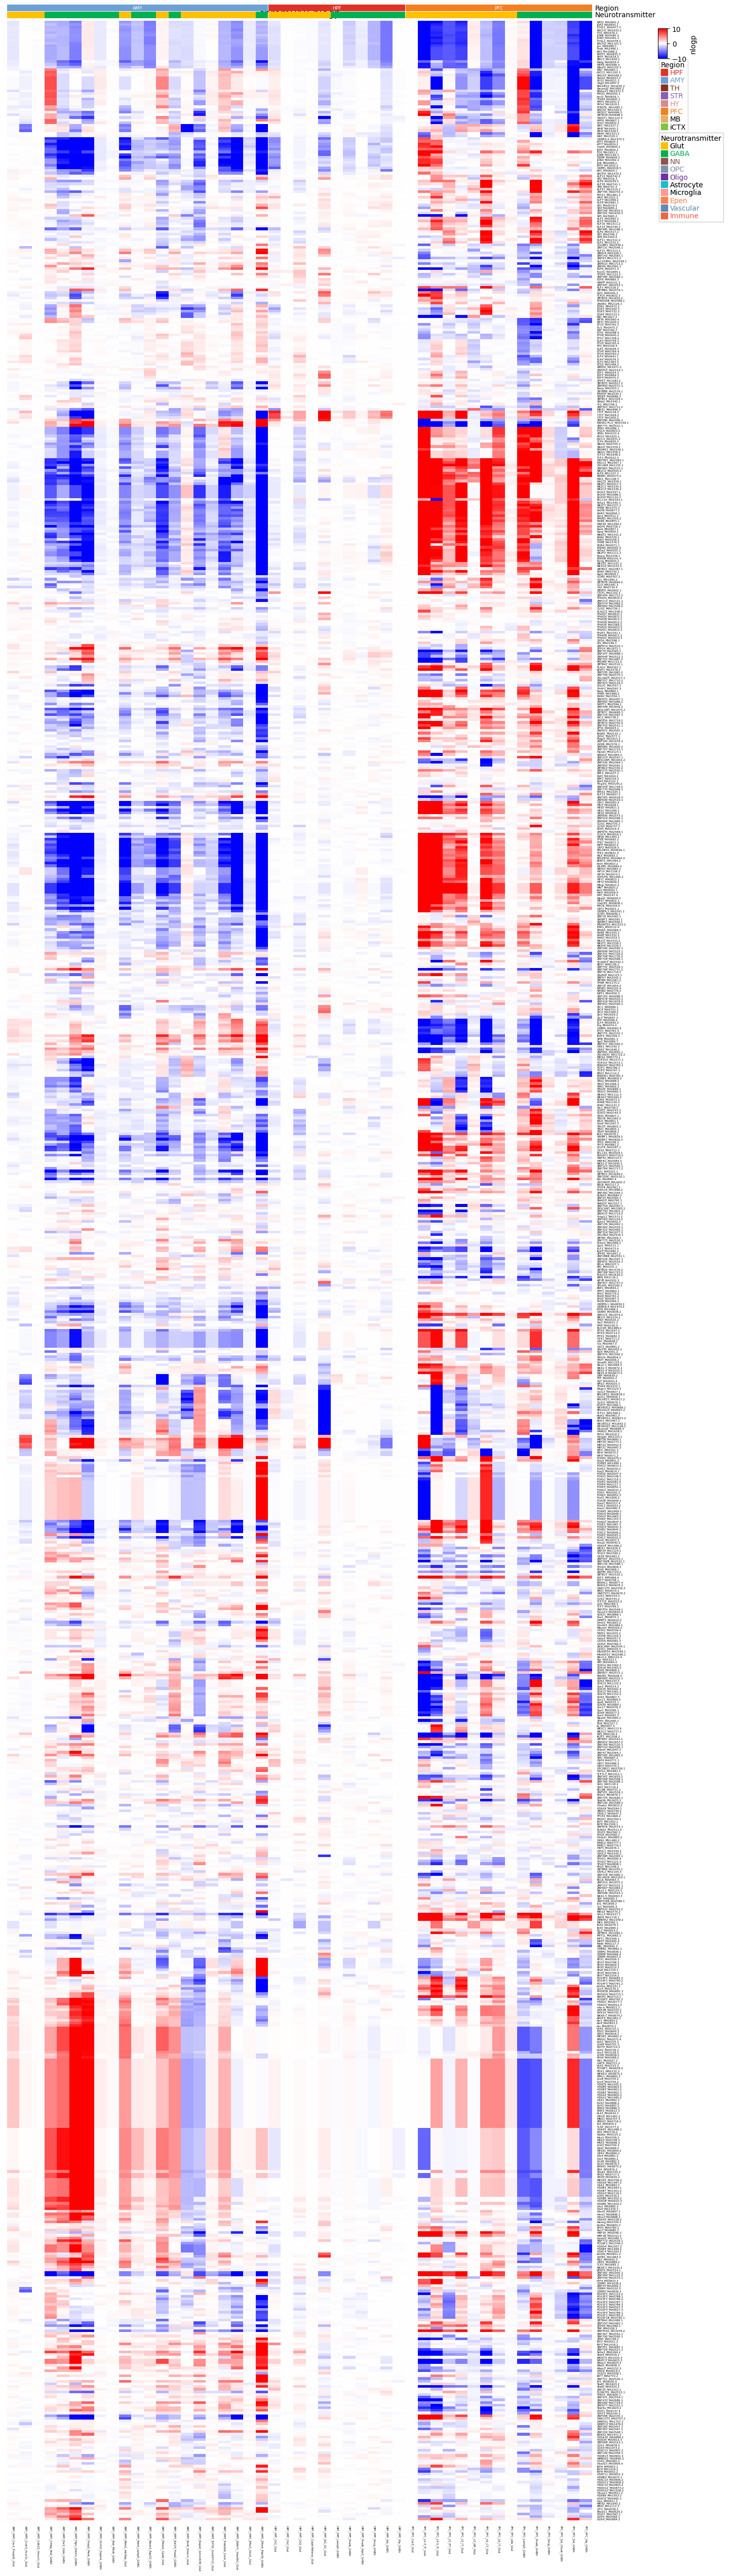

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:1836: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  col_clusters = self.col_split.groupby(cols).apply(


Starting plotting HeatmapAnnotations


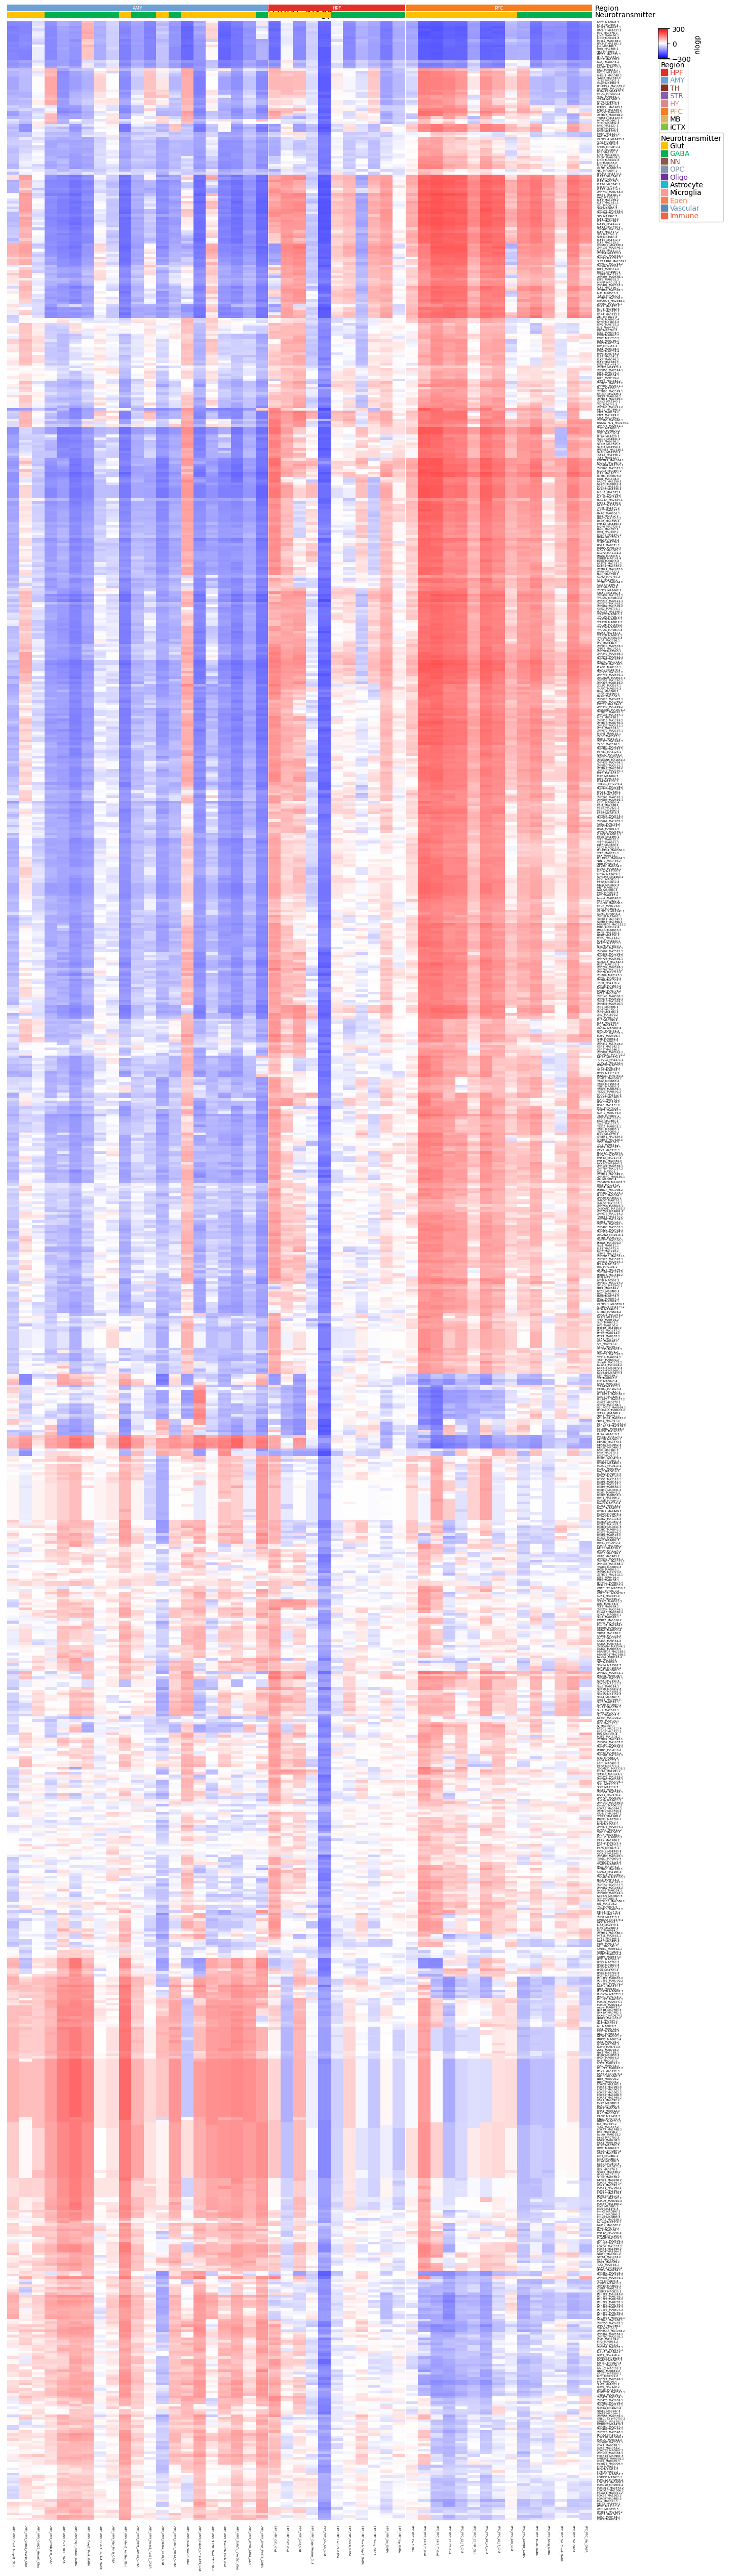

✅ 保存为: /data2st1/junyi/output/atac1112/chromvar/chromVAR_vs_TOBIAS_heatmap.pdf


In [274]:
# ── chromVAR vs TOBIAS 热图，完全相同的行列顺序 ──
df_chrom_hm = df_Dchrom_all_common[
    (df_Dchrom_all_common.Neurotransmitter != 'NN')
].copy()
df_tobias_hm = df_tobias_all_common[
    (df_tobias_all_common.Neurotransmitter != 'NN')
].copy()

# 统一列名
df_chrom_hm = df_chrom_hm.rename(columns={'output_prefix': 'TFid', 'Region Subclass': 'Region subclass'})
df_tobias_hm = df_tobias_hm.rename(columns={'output_prefix': 'TFid', 'Region Subclass': 'Region subclass'})

# 构建两个 mat
mat_chrom = df_chrom_hm.pivot_table(index='TFid', columns='Region subclass', values='nlogp', aggfunc='max').fillna(0)
mat_tobias = df_tobias_hm.pivot_table(index='TFid', columns='Region subclass', values='nlogp', aggfunc='max').fillna(0)

# 取共有行和共有列
common_rows = mat_chrom.index.intersection(mat_tobias.index)
common_cols = mat_chrom.columns.intersection(mat_tobias.columns)
mat_chrom = mat_chrom.loc[common_rows, common_cols]
mat_tobias = mat_tobias.loc[common_rows, common_cols]

# 用 TOBIAS 聚类行顺序
clust = sns.clustermap(mat_tobias, cmap='coolwarm', center=0,
                       row_cluster=True, col_cluster=False,
                       figsize=(6, min(10, mat_tobias.shape[0] * 0.12)))
row_order = mat_tobias.index[clust.dendrogram_row.reordered_ind]
plt.close(clust.fig)

# 统一列顺序
col_meta = df_chrom_hm[['Region subclass', 'Region', 'Neurotransmitter']].drop_duplicates(subset='Region subclass').set_index('Region subclass')
col_meta = col_meta.loc[common_cols].sort_values(['Region', 'Region subclass'])
ordered_cols = col_meta.index.tolist()

mat_chrom = mat_chrom.loc[row_order, ordered_cols]
mat_tobias = mat_tobias.loc[row_order, ordered_cols]

mat_chrom_clip = mat_chrom.clip(-10, 10)
mat_tobias_clip = mat_tobias.clip(-300, 300)

# 列注释
nt = col_meta['Neurotransmitter']
region = col_meta['Region']
col_ha = pch.HeatmapAnnotation(
    Region=pch.anno_simple(region, colors=region_colors, add_text=True),
    Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
    axis=1
)

cmap = LinearSegmentedColormap.from_list("blue_red", ["blue", "white", "red"])

# 保存到 PDF — 分别画两张大图，行名字体缩小以显示全
from matplotlib.backends.backend_pdf import PdfPages
pdf_path = "/data2st1/junyi/output/atac1112/chromvar/chromVAR_vs_TOBIAS_heatmap.pdf"
with PdfPages(pdf_path) as pdf:
    for name, mat, clip_range in [('chromVAR', mat_chrom_clip, (-10, 10)),
                                    ('TOBIAS', mat_tobias_clip, (-300, 300))]:
        n_rows = mat.shape[0]
        fig_width = 15
        fig_height = max(8, n_rows * 0.06)  # 每行 0.06 inch，保证所有行名显示
        plt.figure(figsize=(fig_width, fig_height))
        cm = pch.ClusterMapPlotter(
            data=mat, top_annotation=col_ha, col_split=region,
            row_cluster=False, col_cluster=False,
            show_rownames=True, show_colnames=True,
            cmap=cmap, label='nlogp', vmin=clip_range[0], vmax=clip_range[1], center=0, yticklabels=True,
            yticklabels_kws={'labelsize': 4}, xticklabels_kws={'labelsize': 4},
            col_split_order=['AMY', 'HPF', 'PFC'],
            verbose=0, rasterized=True
        )
        if hasattr(cm, 'ax_heatmap'):
            cm.ax_heatmap.set_title(f'{name} nlogp', fontsize=14)
        # 强制手动调小 y 轴标签字体
        if hasattr(cm, 'ax_row_names'):
            for text in cm.ax_row_names.texts:
                text.set_fontsize(3)
        pdf.savefig(bbox_inches='tight')
        plt.show()
        plt.close()

print(f"✅ 保存为: {pdf_path}")